![image.png](https://i.imgur.com/a3uAqnb.png)

# **🔍 Image Search with EfficientNetV2 & PCA**
In this notebook, we will implement **Image Search** using **EfficientNetV2-Small** for feature extraction and **PCA** for dimensionality reduction.

**Steps:**

1️⃣ **Extract Features** using a **Pretrained EfficientNetV2-S Model**  
2️⃣ **Reduce Dimensions** with **PCA**  
3️⃣ **Find Similar Images** using **Cosine Similarity**  
4️⃣ **Visualize Query & Retrieved Images**  

---

## **📌 Step 1: Load Dataset**
We use **Caltech 101 dataset**, which contains **101 object categories** with high-quality images.


In [ ]:
# Download the dataset
!echo "Downloading 101_Object_Categories for image notebooks"

!curl -L -o 101_ObjectCategories.zip --progress-bar https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip?download=1
!unzip 101_ObjectCategories.zip
!mv caltech-101/101_ObjectCategories.tar.gz ./101_ObjectCategories.tar.gz
!tar -xzf 101_ObjectCategories.tar.gz
!rm 101_ObjectCategories.tar.gz
!ls

In [22]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import random
import os

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load dataset
dataset_path = "101_ObjectCategories"
dataset = ImageFolder(root=dataset_path, transform=transform)

In [23]:
# Select a subset for faster processing
n_images = 1000  # num images to keep in the dataset.
random_indices = random.sample(range(len(dataset)), n_images)
images_subset = Subset(dataset, random_indices)

# Use a Dataloader

...

## **📌 Step 2: Feature Extraction using EfficientNetV2-S**
We use a **pretrained EfficientNetV2-S model** and modify it to **extract features before classification**.


In [24]:
import torch
import torchvision.models as models
from torch import nn
from tqdm import tqdm

# Load pretrained EfficientNetV2-S model
...

# Modify EfficientNetV2-S to extract features before classification

...
# Extract features for all images
...

# Convert to numpy
...

100%|██████████| 16/16 [00:04<00:00,  3.98it/s]


## **📌 Step 3: Apply PCA for Dimensionality Reduction**
Since **EfficientNetV2-S outputs high-dimensional features**, we apply **PCA** to reduce dimensions and speed up search.


In [25]:
from sklearn.decomposition import PCA



## **📌 Step 4: Image Retrieval using Cosine Similarity**
To retrieve similar images:

1️⃣ Compute **cosine similarity** between query image and dataset.  
2️⃣ Retrieve **top 5 most similar images**.  

---

## **🔹 What is Cosine Similarity?**
**Cosine similarity** measures the **angle** between two vectors rather than their **absolute distance**.

✅ **Formula:**
$$
\text{cosine similarity} = \frac{A \cdot B}{\|A\| \|B\|}
$$
where:
- **A, B** are two feature vectors (image embeddings)
- **$\cdot$** represents the dot product
- **$\|A\|$** and **$\|B\|$** are the magnitudes (L2 norm) of the vectors

🚀 **Range:** `[-1, 1]`
- **1.0** → Perfectly similar (same direction)
- **0.0** → Unrelated (orthogonal)
- **-1.0** → Completely opposite

---

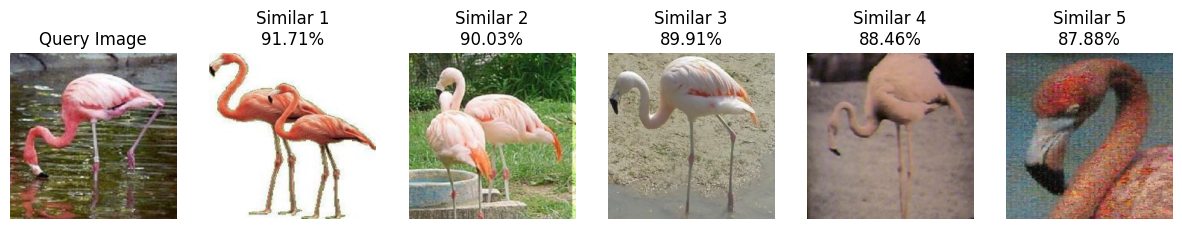

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import torch
import random

# Select a random query image
...
...

# Compute cosine similarity
...
...

# Get top k similar images
...
...

# Display query & retrieved images with similarity scores
...
...

---

# **🔍 Image Search with Vision Transformer (ViT)**
Now let's repeat the same image-search pipeline, but swap **EfficientNetV2-S** (a CNN) for a **Vision Transformer (ViT)**.

🧠 **Why try ViT?**
- **CNNs** like EfficientNetV2 build features hierarchically through **local convolutions** — great at textures and small patterns.
- **ViT** splits the image into **patches**, treats them as a sequence of tokens, and uses **self-attention** so every patch can attend to every other patch from the very first layer — better at capturing **global structure and long-range relationships**.

By running both models on the **same images**, we can compare which one retrieves more visually similar results.

---


## **📌 Step 1: Load a Pretrained ViT
Use **`google/vit-base-patch16-224`** from Hugging Face — a ViT-Base model pretrained on ImageNet-21k and fine-tuned on ImageNet-1k.

- **Patch size:** 16×16 (a 224×224 image → 14×14 = 196 patches)
- **Embedding dim:** 768
- Take the **`[CLS]` token's final hidden state** as the image embedding (a 768-d vector).


In [ ]:
# Install transformers if it's not already available
!pip install -q transformers

In [ ]:
from transformers import ViTModel, ViTImageProcessor
import torch

...
...
...

## **📌 Step 2: Extract ViT Features**
For each image we:
1. **Normalize** it using ViT's image-processor statistics (note: different mean/std than EfficientNet).
2. Run a **forward pass** through ViT.
3. Take the **`[CLS]` token** (`last_hidden_state[:, 0, :]`) as the image embedding.

Reuse the **same `image_tensors`** from earlier, so the comparison with EfficientNetV2 is fair.


In [32]:
from tqdm import tqdm

...
...
...

100%|██████████| 16/16 [00:10<00:00,  1.55it/s]

ViT feature matrix shape: (1000, 768)


## **📌 Step 3: Image Retrieval with ViT Features**
Same cosine-similarity retrieval as before — only the features have changed.

**Skip PCA** here: ViT's 768-d embedding is already much smaller than EfficientNetV2's flattened feature map, so reducing it further is unnecessary for this dataset size.

Display a visualization of the query and the retrieved images.

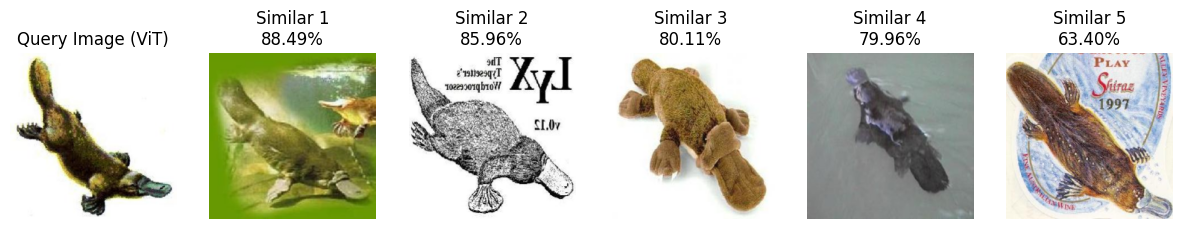

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import random

# Pick a random query image
...
...
...
...


## **📌 Step 4: Side-by-Side — EfficientNetV2 vs ViT**
Let's run **both models on the same query image** and compare their top-5 retrievals row by row.

👀 **Things to look for:**
- Do both models retrieve images from the **same category**?
- Does one model focus more on **texture/color** (typical CNN bias) and the other more on **shape/global layout** (typical ViT bias)?
- Are the **similarity scores** distributed differently? (ViT scores tend to be higher overall because [CLS] embeddings are less sparse than CNN feature maps.)


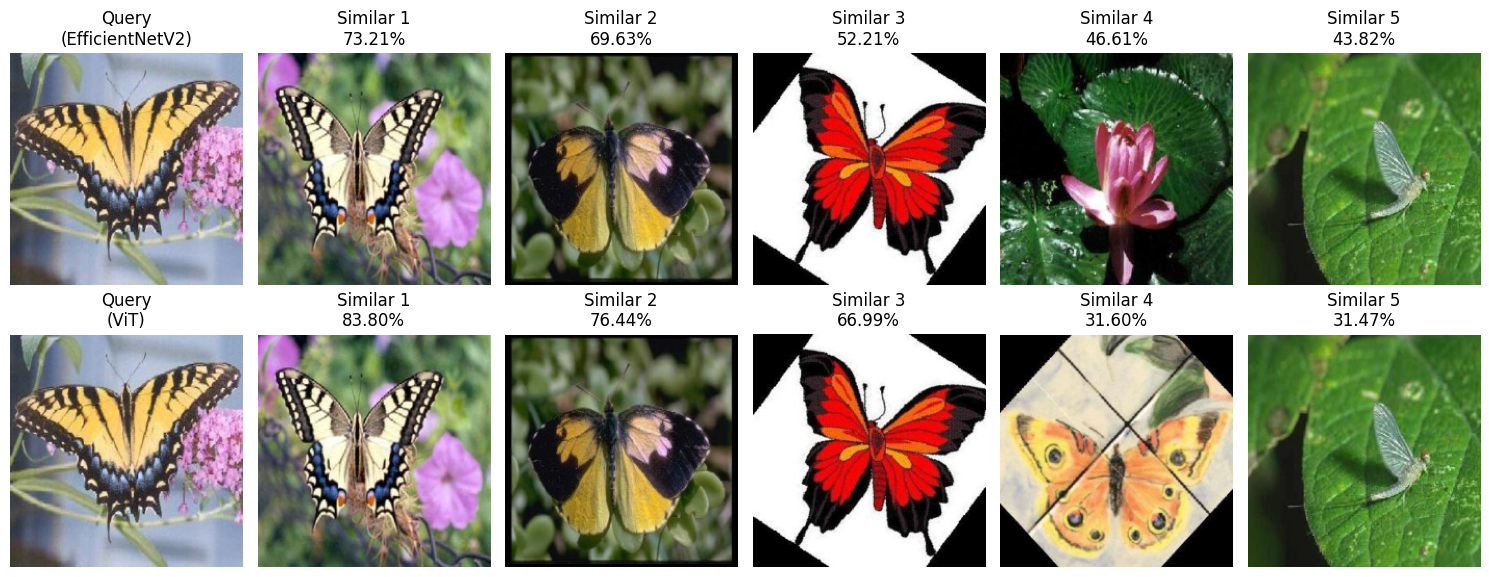

In [34]:
# Same query for both models
...
...
...


### Contributed by: Mohamed Eltayeb

![image.png](https://i.imgur.com/Vqj1JYX.png)

The lab is over, what are you staring at?